# Modelling v2.0 (Balanced) — LR, XGBoost, IndoBERT — 3 Skenario

Notebook ini menggabungkan tiga pipeline modelling ke dalam satu alur kerja, memakai **Data Train
hasil undersampling** (dari `data_splitting__1_.ipynb`) dan **Data Test asli/tidak diubah**:

| Skenario | Data Train (dipakai) | Data Test (dipakai, TIDAK diubah) |
|---|---|---|
| A-Manual   | `v2b_manual_train_balanced.csv` | `v2b_manual_test.csv` |
| A-Gabungan | `v2b_agab_train_balanced.csv`   | `v2b_agab_test.csv` |
| B-Gabungan | `v2b_bgab_train_balanced.csv`   | `v2b_bgab_test.csv` |

Untuk IndoBERT, sumber file sama tapi di folder `data/splits/splits_v2/indobert/` dengan konvensi nama
`{skenario}_idb_train_balanced.csv` / `{skenario}_idb_test.csv`.

**Model yang dijalankan (12 total, 3 skenario x 4 varian):**
1. Logistic Regression (TF-IDF Bigram + Chi-Square)
2. XGBoost tanpa tuning
3. XGBoost dengan tuning (GridSearchCV 5-fold)
4. IndoBERT (fine-tuning penuh)

> **Catatan penting:** karena Data Train sudah diseimbangkan lewat undersampling, `class_weight`/
> `sample_weight`/`compute_class_weight('balanced', ...)` yang tetap dipakai di kode LR/XGBoost/IndoBERT
> di bawah ini sekarang menghasilkan bobot yang **hampir seragam (~1.0 untuk tiap kelas)** karena
> jumlah data per kelas sudah relatif setara — jadi tidak konflik dengan undersampling, hanya jadi
> lapisan pengaman tambahan yang secara praktis netral. Kode tetap dipertahankan apa adanya (tidak
> dihapus) supaya konsisten dengan pipeline v2.0 sebelumnya dan tetap aman kalau ternyata masih ada
> sedikit sisa imbalance setelah undersampling 2-tahap (per layanan x kelas).

## Cell 1 — Setup & Konfigurasi (Gabungan: LR, XGBoost, IndoBERT)

In [2]:
import pandas as pd
import numpy as np
import os, pickle, time, warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, classification_report
)

# ── PATH (disesuaikan dengan struktur_file_update.txt) ────────────────────────
BASE_DIR         = r'C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method'
PREP_DIR         = os.path.join(BASE_DIR, 'data', 'processed')
SPLIT_DIR        = os.path.join(BASE_DIR, 'data', 'splits', 'splits_v3')            # LR/XGBoost
SPLIT_DIR_IDB    = os.path.join(BASE_DIR, 'data', 'splits', 'splits_v3', 'indobert') # IndoBERT
MODEL_DIR        = os.path.join(BASE_DIR, 'models', 'ml_v3')        # LR & XGBoost .pkl
MODEL_DIR_IDB    = os.path.join(BASE_DIR, 'models', 'indobert_v3')  # IndoBERT checkpoint per skenario
RESULT_DIR       = os.path.join(BASE_DIR, 'results')
CM_DIR           = os.path.join(RESULT_DIR, 'confusion_matrix_v3')  # sesuai struktur project
for d in [MODEL_DIR, MODEL_DIR_IDB, RESULT_DIR, CM_DIR]:
    os.makedirs(d, exist_ok=True)

SEED        = 42
LABEL_MAP   = {'keluhan': 0, 'saran': 1, 'pujian': 2}
INV_MAP     = {v: k for k, v in LABEL_MAP.items()}
CLASS_NAMES = ['keluhan', 'saran', 'pujian']

# k_best Chi-Square (dari grid search k sebelumnya, dipertahankan -- SelectKBest
# otomatis meng-cap ke jumlah fitur yang tersedia lewat min(k_best, X.shape[1]),
# jadi tetap aman walau Data Train balanced sekarang lebih kecil dari sebelumnya)
K_A_MANUAL   = 2000
K_A_GABUNGAN = 8000
K_B_GABUNGAN = 10000

# ── Skenario LR / XGBoost -- TRAIN pakai versi balanced, TEST tetap asli ─────
SKENARIO = [
    {'nama': 'A-Manual',   'tr': 'v2b_manual_train_balanced.csv', 'te': 'v2b_manual_test.csv', 'k': K_A_MANUAL},
    {'nama': 'A-Gabungan', 'tr': 'v2b_agab_train_balanced.csv',   'te': 'v2b_agab_test.csv',   'k': K_A_GABUNGAN},
    {'nama': 'B-Gabungan', 'tr': 'v2b_bgab_train_balanced.csv',   'te': 'v2b_bgab_test.csv',   'k': K_B_GABUNGAN},
]

# ── Skenario IndoBERT -- TRAIN pakai versi balanced, TEST tetap asli ─────────
SKENARIO_INDOBERT = [
    {'nama': 'A-Manual',   'tr': 'A_manual_idb_train_balanced.csv',   'te': 'A_manual_idb_test.csv'},
    {'nama': 'A-Gabungan', 'tr': 'A_gabungan_idb_train_balanced.csv', 'te': 'A_gabungan_idb_test.csv'},
    {'nama': 'B-Gabungan', 'tr': 'B_gabungan_idb_train_balanced.csv', 'te': 'B_gabungan_idb_test.csv'},
]

# ── Hasil v1.0 (baseline preprocessing sebelum v2.0) untuk perbandingan ──────
HASIL_V1 = {
    'LR-A-Manual'           : {'acc':79.13,'f1':0.7582,'f1_k':0.8499,'f1_s':0.5893,'f1_p':0.8355},
    'LR-A-Gabungan'         : {'acc':81.20,'f1':0.7675,'f1_k':0.8684,'f1_s':0.5941,'f1_p':0.8401},
    'LR-B-Gabungan'         : {'acc':80.96,'f1':0.7677,'f1_k':0.8677,'f1_s':0.5998,'f1_p':0.8354},
    'XGB-NoTune-A-Manual'   : {'acc':77.86,'f1':0.7473,'f1_k':0.8416,'f1_s':0.5727,'f1_p':0.8275},
    'XGB-NoTune-A-Gabungan' : {'acc':78.80,'f1':0.7458,'f1_k':0.8521,'f1_s':0.5510,'f1_p':0.8344},
    'XGB-NoTune-B-Gabungan' : {'acc':78.29,'f1':0.7417,'f1_k':0.8489,'f1_s':0.5474,'f1_p':0.8290},
    'XGB-Tuned-A-Manual'    : {'acc':79.49,'f1':0.7574,'f1_k':0.8541,'f1_s':0.5880,'f1_p':0.8301},
    'XGB-Tuned-A-Gabungan'  : {'acc':82.27,'f1':0.7750,'f1_k':0.8793,'f1_s':0.5923,'f1_p':0.8532},
    'XGB-Tuned-B-Gabungan'  : {'acc':81.73,'f1':0.7685,'f1_k':0.8774,'f1_s':0.5837,'f1_p':0.8444},
}

# ── Sanity check: pastikan semua file (train balanced + test asli) tersedia ──
print('Cek ketersediaan file LR/XGBoost:')
for s in SKENARIO:
    for key in ['tr', 'te']:
        p = os.path.join(SPLIT_DIR, s[key])
        status = '✅' if os.path.exists(p) else '❌ TIDAK DITEMUKAN'
        print(f'  [{s["nama"]}] {key}: {s[key]:38s} {status}')

print('\nCek ketersediaan file IndoBERT:')
for s in SKENARIO_INDOBERT:
    for key in ['tr', 'te']:
        p = os.path.join(SPLIT_DIR_IDB, s[key])
        status = '✅' if os.path.exists(p) else '❌ TIDAK DITEMUKAN'
        print(f'  [{s["nama"]}] {key}: {s[key]:38s} {status}')

print('\n✅ Setup selesai! Kalau ada file ❌ di atas, jalankan/cek ulang data_splitting__1_.ipynb dulu.')

Cek ketersediaan file LR/XGBoost:
  [A-Manual] tr: v2b_manual_train_balanced.csv          ✅
  [A-Manual] te: v2b_manual_test.csv                    ✅
  [A-Gabungan] tr: v2b_agab_train_balanced.csv            ✅
  [A-Gabungan] te: v2b_agab_test.csv                      ✅
  [B-Gabungan] tr: v2b_bgab_train_balanced.csv            ✅
  [B-Gabungan] te: v2b_bgab_test.csv                      ✅

Cek ketersediaan file IndoBERT:
  [A-Manual] tr: A_manual_idb_train_balanced.csv        ✅
  [A-Manual] te: A_manual_idb_test.csv                  ✅
  [A-Gabungan] tr: A_gabungan_idb_train_balanced.csv      ✅
  [A-Gabungan] te: A_gabungan_idb_test.csv                ✅
  [B-Gabungan] tr: B_gabungan_idb_train_balanced.csv      ✅
  [B-Gabungan] te: B_gabungan_idb_test.csv                ✅

✅ Setup selesai! Kalau ada file ❌ di atas, jalankan/cek ulang data_splitting__1_.ipynb dulu.


## Cell 2 — Fungsi TF-IDF Bigram + Chi-Square + Evaluasi (LR & XGBoost)

In [3]:
def build_features(train_texts, train_labels, k_best, max_features=100000):
    """TF-IDF Bigram (1,2) + Chi-Square -- v2.0 (Data Train sudah balanced)."""
    tfidf = TfidfVectorizer(
        ngram_range   = (1, 2),
        max_features  = max_features,
        sublinear_tf  = True,
        min_df        = 2,
        token_pattern = r'[a-zA-Z_][a-zA-Z_]+',
    )
    X     = tfidf.fit_transform(train_texts)
    y_enc = np.array([LABEL_MAP[l] for l in train_labels])
    sel   = SelectKBest(chi2, k=min(k_best, X.shape[1]))
    X_sel = sel.fit_transform(X, y_enc)

    feat_names   = np.array(tfidf.get_feature_names_out())[sel.get_support()]
    negasi_feats = [f for f in feat_names if '_' in f and '__' not in f]
    bigram_feats = [f for f in feat_names if ' ' in f]
    print(f'  TF-IDF: {X.shape[1]:,} -> Chi2 k={k_best:,} -> {X_sel.shape[1]:,} fitur')
    print(f'  Token tidak_X: {len(negasi_feats):,} | Bigram: {len(bigram_feats):,}')
    return tfidf, sel, X_sel, y_enc


def get_xy(skenario, split_dir):
    """Load data (Train balanced, Test asli) dan encode label."""
    df_tr = pd.read_csv(os.path.join(split_dir, skenario['tr']))
    df_te = pd.read_csv(os.path.join(split_dir, skenario['te']))
    X_tr  = df_tr['text_v2'].fillna('').values
    y_tr  = df_tr['label_pks'].values
    X_te  = df_te['text_v2'].fillna('').values
    y_te  = np.array([LABEL_MAP[l] for l in df_te['label_pks'].values])
    print(f'  Train (balanced): {len(df_tr):,} | Test (asli): {len(df_te):,}')
    return X_tr, y_tr, X_te, y_te


def get_sw(y_train):
    sw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    return np.array([sw[y] for y in y_train])


def evaluate(y_test, y_pred, nama, v1_key=None):
    """Evaluasi model dan tampilkan hasil + perbandingan v1.0 (preprocessing lama)."""
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1s  = f1_score(y_test, y_pred, average=None, labels=[0,1,2], zero_division=0)
    prec = precision_score(y_test, y_pred, average=None, labels=[0,1,2], zero_division=0)
    rec  = recall_score(y_test, y_pred, average=None, labels=[0,1,2], zero_division=0)

    print(f'\n{"="*60}')
    print(f'HASIL -- {nama}')
    print(f'{"="*60}')
    print(f'  Accuracy   : {acc*100:.2f}%')
    print(f'  Macro F1   : {f1:.4f}')
    print(f'  F1 Keluhan : {f1s[0]:.4f}  Prec:{prec[0]:.4f}  Rec:{rec[0]:.4f}')
    print(f'  F1 Saran   : {f1s[1]:.4f}  Prec:{prec[1]:.4f}  Rec:{rec[1]:.4f}')
    print(f'  F1 Pujian  : {f1s[2]:.4f}  Prec:{prec[2]:.4f}  Rec:{rec[2]:.4f}')
    print()
    print(classification_report(y_test, y_pred,
          target_names=CLASS_NAMES, digits=4, zero_division=0))

    if v1_key and v1_key in HASIL_V1:
        v1 = HASIL_V1[v1_key]
        print(f'  Perbandingan vs v1.0 ({v1_key}):')
        for label, k_v1, v2_val in [
            ('Accuracy', 'acc',  acc*100),
            ('Macro F1', 'f1',   f1),
            ('F1 Saran', 'f1_s', f1s[1]),
        ]:
            delta = v2_val - v1[k_v1]
            ikon  = 'v' if delta>0.001 else ('x' if delta<-0.001 else '-')
            print(f'    {label:10s}: {v1[k_v1]:.4f} -> {v2_val:.4f}  [{ikon}] {delta:+.4f}')

    return {'nama':nama,'acc':acc,'f1':f1,'f1_k':f1s[0],'f1_s':f1s[1],'f1_p':f1s[2]}


def save_model(model, vec_dict, nama):
    key = nama.replace('-','_').replace(' ','_')
    pickle.dump(model, open(os.path.join(MODEL_DIR, f'{key}.pkl'), 'wb'))
    pickle.dump(vec_dict, open(os.path.join(MODEL_DIR, f'vec_{key}.pkl'), 'wb'))
    print(f'  ✅ Model tersimpan: {key}.pkl')


print('✅ Fungsi siap!')
print(f'\nSkenario yang akan diuji (Data Train balanced, Data Test asli):')
for s in SKENARIO:
    print(f'  {s["nama"]:12s} k={s["k"]:,}')

✅ Fungsi siap!

Skenario yang akan diuji (Data Train balanced, Data Test asli):
  A-Manual     k=2,000
  A-Gabungan   k=8,000
  B-Gabungan   k=10,000


In [7]:
# ============================================================
# Grid Search k_best (Chi-Square) -- per Skenario, pakai Data Train Balanced
# Dievaluasi via Stratified K-Fold CV di TRAIN SAJA (test set tidak disentuh)
# ============================================================
from sklearn.model_selection import StratifiedKFold, cross_val_score
import time

K_CANDIDATES = [500, 1000, 2000, 3000, 5000, 8000, 10000, 15000, 20000]
CV_FOLDS_K   = 5

def grid_search_k_best(skenario, split_dir, k_candidates=K_CANDIDATES, cv_folds=CV_FOLDS_K, max_features=100000):
    """Cari k_best optimal (Chi-Square) untuk satu skenario, dievaluasi LR & XGBoost sekaligus."""
    df_tr = pd.read_csv(os.path.join(split_dir, skenario['tr']))
    X_tr_text = df_tr['text_v2'].fillna('').values
    y_tr = np.array([LABEL_MAP[l] for l in df_tr['label_pks'].values])

    tfidf = TfidfVectorizer(
        ngram_range=(1, 2), max_features=max_features, sublinear_tf=True,
        min_df=2, token_pattern=r'[a-zA-Z_][a-zA-Z_]+',
    )
    X_full = tfidf.fit_transform(X_tr_text)
    vocab_size = X_full.shape[1]
    print(f"\n{'='*60}")
    print(f"[{skenario['nama']}] Train (balanced): {len(df_tr):,} baris | Vocab TF-IDF: {vocab_size:,} fitur")
    print(f"{'='*60}")

    valid_k = sorted(set(k for k in k_candidates if k < vocab_size) | {vocab_size})
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=SEED)
    results = []

    for k in valid_k:
        sel = SelectKBest(chi2, k=min(k, vocab_size))
        X_sel = sel.fit_transform(X_full, y_tr)
        row = {'skenario': skenario['nama'], 'k': k, 'n_fitur_aktual': X_sel.shape[1]}

        # -- Logistic Regression --
        lr = LogisticRegression(multi_class='multinomial', solver='lbfgs', C=1.0,
                                 max_iter=1000, class_weight='balanced',
                                 random_state=SEED, n_jobs=-1)
        t0 = time.time()
        scores_lr = cross_val_score(lr, X_sel, y_tr, cv=cv, scoring='f1_macro', n_jobs=-1)
        row['LR_f1_mean'] = scores_lr.mean()
        row['LR_f1_std']  = scores_lr.std()
        row['LR_time_s']  = round(time.time() - t0, 1)

        # -- XGBoost (default params, tanpa tuning -- cukup untuk seleksi k) --
        xgb_model = xgb.XGBClassifier(
            objective='multi:softmax', num_class=3, eval_metric='mlogloss',
            n_estimators=300, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8, device='cpu',
            random_state=SEED, n_jobs=-1, use_label_encoder=False,
        )
        t0 = time.time()
        scores_xgb = cross_val_score(xgb_model, X_sel, y_tr, cv=cv, scoring='f1_macro', n_jobs=1)
        row['XGB_f1_mean'] = scores_xgb.mean()
        row['XGB_f1_std']  = scores_xgb.std()
        row['XGB_time_s']  = round(time.time() - t0, 1)

        results.append(row)
        print(f"  k={k:6,} -> fitur={row['n_fitur_aktual']:6,} | "
              f"LR F1={row['LR_f1_mean']:.4f}±{row['LR_f1_std']:.4f} ({row['LR_time_s']}s) | "
              f"XGB F1={row['XGB_f1_mean']:.4f}±{row['XGB_f1_std']:.4f} ({row['XGB_time_s']}s)")

    return pd.DataFrame(results)


# ── Jalankan untuk ketiga skenario ────────────────────────────────────────
print("PERINGATAN: cell ini cukup berat (CV x banyak nilai k x 2 model) -- bisa "
      "beberapa menit hingga puluhan menit tergantung ukuran data. Kalau mau lebih "
      "cepat, kurangi K_CANDIDATES atau CV_FOLDS_K di atas dulu.")

hasil_k_search = {}
for s in SKENARIO:
    hasil_k_search[s['nama']] = grid_search_k_best(s, SPLIT_DIR)

# Gabungkan semua hasil jadi satu tabel
df_k_search = pd.concat(hasil_k_search.values(), ignore_index=True)
df_k_search.to_csv(os.path.join(RESULT_DIR, 'grid_search_k_best.csv'), index=False)
print(f"\n✅ Tersimpan -> {os.path.join(RESULT_DIR, 'grid_search_k_best.csv')}")
df_k_search

PERINGATAN: cell ini cukup berat (CV x banyak nilai k x 2 model) -- bisa beberapa menit hingga puluhan menit tergantung ukuran data. Kalau mau lebih cepat, kurangi K_CANDIDATES atau CV_FOLDS_K di atas dulu.

[A-Manual] Train (balanced): 6,118 baris | Vocab TF-IDF: 6,668 fitur
  k=   500 -> fitur=   500 | LR F1=0.7858±0.0056 (2.3s) | XGB F1=0.7735±0.0100 (6.0s)
  k= 1,000 -> fitur= 1,000 | LR F1=0.7957±0.0064 (1.5s) | XGB F1=0.7703±0.0112 (7.4s)
  k= 2,000 -> fitur= 2,000 | LR F1=0.8012±0.0067 (1.5s) | XGB F1=0.7685±0.0140 (8.7s)
  k= 3,000 -> fitur= 3,000 | LR F1=0.8004±0.0090 (1.6s) | XGB F1=0.7683±0.0141 (10.5s)
  k= 5,000 -> fitur= 5,000 | LR F1=0.7930±0.0058 (0.2s) | XGB F1=0.7667±0.0138 (12.0s)
  k= 6,668 -> fitur= 6,668 | LR F1=0.7837±0.0078 (0.2s) | XGB F1=0.7673±0.0134 (16.4s)

[A-Gabungan] Train (balanced): 19,427 baris | Vocab TF-IDF: 16,044 fitur
  k=   500 -> fitur=   500 | LR F1=0.8236±0.0042 (0.2s) | XGB F1=0.8189±0.0061 (16.2s)
  k= 1,000 -> fitur= 1,000 | LR F1=0.8358±0

,skenario,k,n_fitur_aktual,LR_f1_mean,LR_f1_std,LR_time_s,XGB_f1_mean,XGB_f1_std,XGB_time_s
0,A-Manual,500,500,0.785826,0.005599,2.3,0.773508,0.010042,6.0
1,A-Manual,1000,1000,0.795693,0.006353,1.5,0.770257,0.011232,7.4
2,A-Manual,2000,2000,0.801200,0.006651,1.5,0.768524,0.014040,8.7
3,A-Manual,3000,3000,0.800405,0.009008,1.6,0.768312,0.014127,10.5
4,A-Manual,5000,5000,0.792953,0.005781,0.2,0.766707,0.013820,12.0
5,A-Manual,6668,6668,0.783699,0.007845,0.2,0.767314,0.013415,16.4
6,A-Gabungan,500,500,0.823611,0.004154,0.2,0.818948,0.006089,16.2
7,A-Gabungan,1000,1000,0.835843,0.003862,0.2,0.821631,0.006153,18.9
8,A-Gabungan,2000,2000,0.841403,0.003000,0.3,0.821516,0.007211,23.4
9,A-Gabungan,3000,3000,0.844677,0.003611,0.3,0.822139,0.005185,25.9


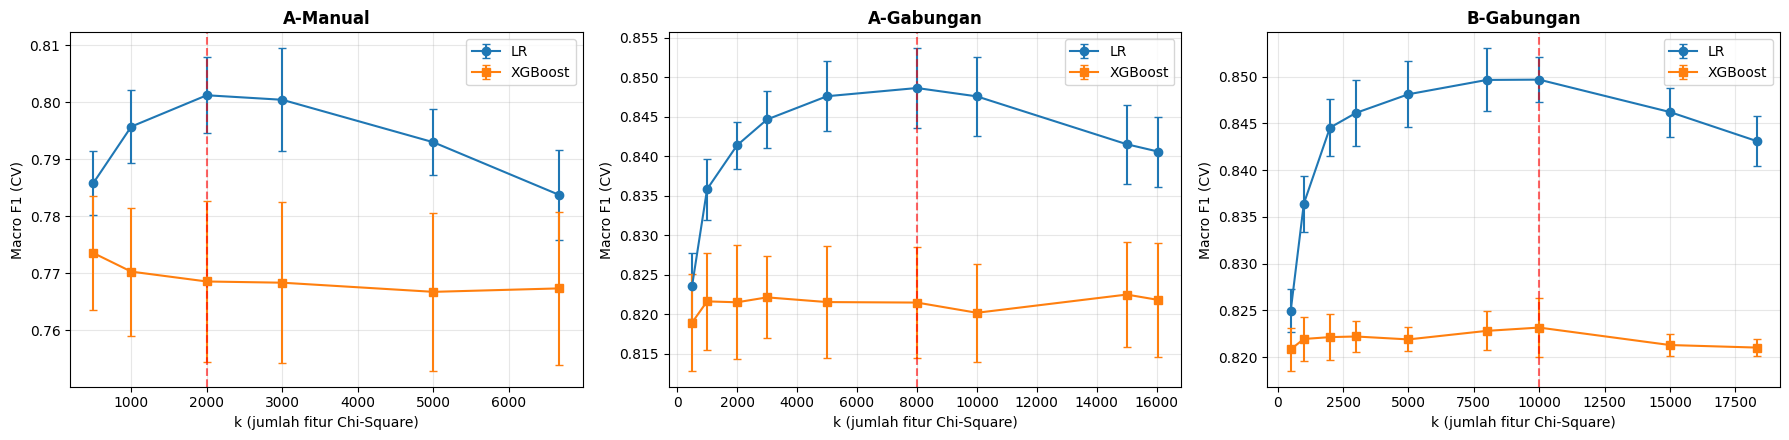


REKOMENDASI k_best PER SKENARIO (avg F1 LR & XGBoost tertinggi):
  A-Manual    : k = 2,000
  A-Gabungan  : k = 8,000
  B-Gabungan  : k = 10,000

Untuk pakai hasil ini, update SKENARIO di Cell 1 (ganti K_MANUAL/K_GABUNGAN
atau langsung isi field 'k' tiap skenario) dengan angka rekomendasi di atas,
lalu jalankan ulang dari Cell 3.


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(SKENARIO), figsize=(6*len(SKENARIO), 4.5))
if len(SKENARIO) == 1:
    axes = [axes]

K_BEST_REKOMENDASI = {}

for ax, s in zip(axes, SKENARIO):
    sub = df_k_search[df_k_search['skenario'] == s['nama']].sort_values('k')
    ax.errorbar(sub['k'], sub['LR_f1_mean'], yerr=sub['LR_f1_std'], marker='o', label='LR', capsize=3)
    ax.errorbar(sub['k'], sub['XGB_f1_mean'], yerr=sub['XGB_f1_std'], marker='s', label='XGBoost', capsize=3)
    ax.set_title(s['nama'], fontweight='bold')
    ax.set_xlabel('k (jumlah fitur Chi-Square)')
    ax.set_ylabel('Macro F1 (CV)')
    ax.legend(); ax.grid(True, alpha=0.3)

    # Rekomendasi: k dengan rata-rata F1 (LR+XGB)/2 tertinggi
    sub = sub.copy()
    sub['avg_f1'] = (sub['LR_f1_mean'] + sub['XGB_f1_mean']) / 2
    best_row = sub.loc[sub['avg_f1'].idxmax()]
    K_BEST_REKOMENDASI[s['nama']] = int(best_row['k'])
    ax.axvline(best_row['k'], color='red', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'grid_search_k_best_plot.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*50)
print("REKOMENDASI k_best PER SKENARIO (avg F1 LR & XGBoost tertinggi):")
print("="*50)
for nama, k in K_BEST_REKOMENDASI.items():
    print(f"  {nama:12s}: k = {k:,}")

print("\nUntuk pakai hasil ini, update SKENARIO di Cell 1 (ganti K_MANUAL/K_GABUNGAN\n"
      "atau langsung isi field 'k' tiap skenario) dengan angka rekomendasi di atas,\n"
      "lalu jalankan ulang dari Cell 3.")

## Cell 3 — Logistic Regression (A-Manual, A-Gabungan, B-Gabungan) — Data Balanced

In [11]:
hasil_lr = []

for s in SKENARIO:
    nama   = f'LR-v2-{s["nama"]}'
    v1_key = f'LR-{s["nama"]}'
    print(f'\n{"─"*60}')
    print(f'SKENARIO: {nama} (k={s["k"]:,})')
    print(f'{"─"*60}')

    X_tr, y_tr, X_te, y_te = get_xy(s, SPLIT_DIR)
    tfidf, sel, X_train, y_train = build_features(X_tr, y_tr, s['k'])
    X_test = sel.transform(tfidf.transform(X_te))

    sw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    lr = LogisticRegression(
        multi_class='multinomial', solver='lbfgs', C=1.0,
        max_iter=1000, class_weight=dict(enumerate(sw)),
        random_state=SEED, n_jobs=-1,
    )
    t0 = time.time()
    lr.fit(X_train, y_train)
    print(f'  Training LR: {time.time()-t0:.2f}s')

    hasil = evaluate(y_te, lr.predict(X_test), nama, v1_key)
    hasil_lr.append(hasil)
    save_model(lr, {'tfidf':tfidf,'selector':sel}, nama)

print('\n✅ LR selesai!')


────────────────────────────────────────────────────────────
SKENARIO: LR-v2-A-Manual (k=2,000)
────────────────────────────────────────────────────────────
  Train (balanced): 6,118 | Test (asli): 1,530
  TF-IDF: 6,668 -> Chi2 k=2,000 -> 2,000 fitur
  Token tidak_X: 208 | Bigram: 1,065
  Training LR: 0.06s

HASIL -- LR-v2-A-Manual
  Accuracy   : 78.89%
  Macro F1   : 0.7929
  F1 Keluhan : 0.7778  Prec:0.7709  Rec:0.7848
  F1 Saran   : 0.7381  Prec:0.7190  Rec:0.7583
  F1 Pujian  : 0.8629  Prec:0.9014  Rec:0.8276

              precision    recall  f1-score   support

     keluhan     0.7709    0.7848    0.7778       553
       saran     0.7190    0.7583    0.7381       513
      pujian     0.9014    0.8276    0.8629       464

    accuracy                         0.7889      1530
   macro avg     0.7971    0.7902    0.7929      1530
weighted avg     0.7931    0.7889    0.7903      1530

  Perbandingan vs v1.0 (LR-A-Manual):
    Accuracy  : 79.1300 -> 78.8889  [x] -0.2411
    Macro F1

## Cell 4 — XGBoost NoTune (A-Manual, A-Gabungan, B-Gabungan) — Data Balanced

In [12]:
hasil_notune = []

for s in SKENARIO:
    nama   = f'XGB-v2-NoTune-{s["nama"]}'
    v1_key = f'XGB-NoTune-{s["nama"]}'
    print(f'\n{"─"*60}')
    print(f'SKENARIO: {nama} (k={s["k"]:,})')
    print(f'{"─"*60}')

    X_tr, y_tr, X_te, y_te = get_xy(s, SPLIT_DIR)
    tfidf, sel, X_train, y_train = build_features(X_tr, y_tr, s['k'])
    X_test = sel.transform(tfidf.transform(X_te))
    sw_arr = get_sw(y_train)

    model = xgb.XGBClassifier(
        objective='multi:softmax', num_class=3,
        eval_metric='mlogloss',
        n_estimators=300, max_depth=6,
        learning_rate=0.1, subsample=0.8,
        colsample_bytree=0.8,
        device='cpu', random_state=SEED,
        n_jobs=-1, use_label_encoder=False,
    )
    t0 = time.time()
    model.fit(X_train, y_train, sample_weight=sw_arr,
              eval_set=[(X_test, y_te)], verbose=False)
    print(f'  Training: {time.time()-t0:.1f}s')

    hasil = evaluate(y_te, model.predict(X_test), nama, v1_key)
    hasil_notune.append(hasil)
    save_model(model, {'tfidf':tfidf,'selector':sel}, nama)

print('\n✅ XGBoost NoTune selesai!')


────────────────────────────────────────────────────────────
SKENARIO: XGB-v2-NoTune-A-Manual (k=2,000)
────────────────────────────────────────────────────────────
  Train (balanced): 6,118 | Test (asli): 1,530
  TF-IDF: 6,668 -> Chi2 k=2,000 -> 2,000 fitur
  Token tidak_X: 208 | Bigram: 1,065
  Training: 3.8s

HASIL -- XGB-v2-NoTune-A-Manual
  Accuracy   : 77.78%
  Macro F1   : 0.7819
  F1 Keluhan : 0.7558  Prec:0.7707  Rec:0.7414
  F1 Saran   : 0.7339  Prec:0.7043  Rec:0.7661
  F1 Pujian  : 0.8562  Prec:0.8795  Rec:0.8341

              precision    recall  f1-score   support

     keluhan     0.7707    0.7414    0.7558       553
       saran     0.7043    0.7661    0.7339       513
      pujian     0.8795    0.8341    0.8562       464

    accuracy                         0.7778      1530
   macro avg     0.7848    0.7805    0.7819      1530
weighted avg     0.7814    0.7778    0.7789      1530

  Perbandingan vs v1.0 (XGB-NoTune-A-Manual):
    Accuracy  : 77.8600 -> 77.7778  [x] 

## Cell 5 — XGBoost Tuned (GridSearchCV 5-Fold) — Data Balanced

Dipecah jadi 3 sub-cell (5a/5b/5c) seperti sebelumnya karena tiap skenario butuh waktu cukup lama.
Karena Data Train sekarang lebih kecil (hasil undersampling), estimasi waktu di tiap sub-cell
kemungkinan **lebih cepat** dari estimasi lama (~22/90/90 menit).

In [13]:
PARAM_GRID = {
    'n_estimators'    : [300, 500],
    'max_depth'       : [4, 6, 8],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'subsample'       : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}
print(f'72 kombinasi x 5 fold = 360 fits')

hasil_tuned = []  # list hasil tuned (diisi bertahap per cell 5a/5b/5c)

def run_tuned(s, hasil_tuned_list):
    nama   = f'XGB-v2-Tuned-{s["nama"]}'
    v1_key = f'XGB-Tuned-{s["nama"]}'
    print(f'\n{"="*60}')
    print(f'SKENARIO: {nama} (k={s["k"]:,})')
    print(f'{"="*60}')

    X_tr, y_tr, X_te, y_te = get_xy(s, SPLIT_DIR)
    tfidf, sel, X_train, y_train = build_features(X_tr, y_tr, s['k'])
    X_test = sel.transform(tfidf.transform(X_te))
    sw_arr = get_sw(y_train)

    base_xgb = xgb.XGBClassifier(
        objective='multi:softmax', num_class=3,
        eval_metric='mlogloss', device='cpu',
        random_state=SEED, n_jobs=1,
        use_label_encoder=False,
    )
    cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    grid = GridSearchCV(
        base_xgb, PARAM_GRID, cv=cv,
        scoring='f1_macro', n_jobs=-1,
        verbose=1, refit=False,
    )
    t0 = time.time()
    grid.fit(X_train, y_train, sample_weight=sw_arr)
    print(f'\nSelesai: {(time.time()-t0)/60:.1f} menit')
    print(f'Best params : {grid.best_params_}')
    print(f'Best CV F1  : {grid.best_score_:.4f}')

    pd.DataFrame(grid.cv_results_).to_csv(
        os.path.join(RESULT_DIR, 'cv', f'cv_{nama.replace("-","_")}.csv'), index=False)

    best = xgb.XGBClassifier(
        objective='multi:softmax', num_class=3,
        eval_metric='mlogloss', device='cpu',
        random_state=SEED, n_jobs=-1,
        use_label_encoder=False, **grid.best_params_
    )
    t0 = time.time()
    best.fit(X_train, y_train, sample_weight=sw_arr,
             eval_set=[(X_test, y_te)], verbose=False)
    print(f'Retrain selesai ({time.time()-t0:.1f}s)')

    hasil = evaluate(y_te, best.predict(X_test), nama, v1_key)
    hasil_tuned_list.append(hasil)
    save_model(best, {'tfidf':tfidf,'selector':sel}, nama)
    return hasil_tuned_list

os.makedirs(os.path.join(RESULT_DIR, 'cv'), exist_ok=True)
print('✅ Fungsi run_tuned siap!')

72 kombinasi x 5 fold = 360 fits
✅ Fungsi run_tuned siap!


### Cell 5a — XGBoost Tuned: A-Manual

In [14]:
s_manual = SKENARIO[0]  # A-Manual
hasil_tuned = run_tuned(s_manual, hasil_tuned)
print('\n✅ XGB Tuned A-Manual selesai! Lanjut ke Cell 5b.')


SKENARIO: XGB-v2-Tuned-A-Manual (k=2,000)
  Train (balanced): 6,118 | Test (asli): 1,530
  TF-IDF: 6,668 -> Chi2 k=2,000 -> 2,000 fitur
  Token tidak_X: 208 | Bigram: 1,065
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Selesai: 5.0 menit
Best params : {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 500, 'subsample': 1.0}
Best CV F1  : 0.7724
Retrain selesai (4.0s)

HASIL -- XGB-v2-Tuned-A-Manual
  Accuracy   : 77.52%
  Macro F1   : 0.7792
  F1 Keluhan : 0.7523  Prec:0.7694  Rec:0.7360
  F1 Saran   : 0.7320  Prec:0.7025  Rec:0.7641
  F1 Pujian  : 0.8534  Prec:0.8736  Rec:0.8341

              precision    recall  f1-score   support

     keluhan     0.7694    0.7360    0.7523       553
       saran     0.7025    0.7641    0.7320       513
      pujian     0.8736    0.8341    0.8534       464

    accuracy                         0.7752      1530
   macro avg     0.7818    0.7781    0.7792      1530
weighted avg     0.7786    0.7752    0.

### Cell 5b — XGBoost Tuned: A-Gabungan

In [15]:
s_agab = SKENARIO[1]  # A-Gabungan
hasil_tuned = run_tuned(s_agab, hasil_tuned)
print('\n✅ XGB Tuned A-Gabungan selesai! Lanjut ke Cell 5c.')


SKENARIO: XGB-v2-Tuned-A-Gabungan (k=8,000)
  Train (balanced): 19,427 | Test (asli): 4,857
  TF-IDF: 16,044 -> Chi2 k=8,000 -> 8,000 fitur
  Token tidak_X: 963 | Bigram: 5,677
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Selesai: 23.9 menit
Best params : {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 8, 'n_estimators': 500, 'subsample': 1.0}
Best CV F1  : 0.8347
Retrain selesai (43.9s)

HASIL -- XGB-v2-Tuned-A-Gabungan
  Accuracy   : 83.71%
  Macro F1   : 0.8368
  F1 Keluhan : 0.8029  Prec:0.8360  Rec:0.7724
  F1 Saran   : 0.7981  Prec:0.7652  Rec:0.8339
  F1 Pujian  : 0.9095  Prec:0.9140  Rec:0.9051

              precision    recall  f1-score   support

     keluhan     0.8360    0.7724    0.8029      1643
       saran     0.7652    0.8339    0.7981      1571
      pujian     0.9140    0.9051    0.9095      1643

    accuracy                         0.8371      4857
   macro avg     0.8384    0.8371    0.8368      4857
weighted avg     0.8395    0.83

### Cell 5c — XGBoost Tuned: B-Gabungan

In [16]:
s_bgab = SKENARIO[2]  # B-Gabungan
hasil_tuned = run_tuned(s_bgab, hasil_tuned)
print('\n✅ XGB Tuned B-Gabungan selesai! Lanjut ke Cell 6 (Setup IndoBERT).')


SKENARIO: XGB-v2-Tuned-B-Gabungan (k=10,000)
  Train (balanced): 22,754 | Test (asli): 1,530
  TF-IDF: 18,319 -> Chi2 k=10,000 -> 10,000 fitur
  Token tidak_X: 1,231 | Bigram: 7,341
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Selesai: 27.8 menit
Best params : {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 8, 'n_estimators': 500, 'subsample': 1.0}
Best CV F1  : 0.8384
Retrain selesai (36.5s)

HASIL -- XGB-v2-Tuned-B-Gabungan
  Accuracy   : 84.64%
  Macro F1   : 0.8465
  F1 Keluhan : 0.8131  Prec:0.8381  Rec:0.7896
  F1 Saran   : 0.8100  Prec:0.7749  Rec:0.8485
  F1 Pujian  : 0.9164  Prec:0.9320  Rec:0.9014

              precision    recall  f1-score   support

     keluhan     0.8381    0.7896    0.8131       518
       saran     0.7749    0.8485    0.8100       495
      pujian     0.9320    0.9014    0.9164       517

    accuracy                         0.8464      1530
   macro avg     0.8483    0.8465    0.8465      1530
weighted avg     0.8494   

## Cell 6 — Setup IndoBERT (Tokenizer, Dataset, Fungsi Training/Evaluasi)

Konfigurasi & referensi parameter dipertahankan sama persis dengan notebook `04_IndoBERT_A_Gabungan.ipynb`
yang sudah Anda buat sebelumnya (lr=2e-5, epoch=5, batch=16, max_length=128, warmup 10%, class weight
balanced), sekarang digeneralisasi supaya bisa dipakai untuk ketiga skenario secara berurutan.

In [4]:
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoConfig
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW
import random

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('CPU mode')

# ── Konfigurasi IndoBERT (Referensi: Braja et al., 2023; Zaidan et al., 2024; Sagama et al., 2023; Shaw et al., 2025) ─
MODEL_NAME    = 'indobenchmark/indobert-base-p1'
MAX_LENGTH    = 128   # Braja et al. (2023); Shaw et al. (2025)
EPOCHS        = 5     # Braja et al. (2023): epoch 5 optimal
BATCH_SIZE    = 16    # Zaidan et al. (2024): batch 16 RTX GPU
LEARNING_RATE = 2e-5  # Braja et al. (2023); Sagama et al. (2023)
WARMUP_RATIO  = 0.1   # Sagama et al. (2023): 10% warmup linear scheduler

print(f'\nKonfigurasi IndoBERT:')
print(f'  Model      : {MODEL_NAME}')
print(f'  Max Length : {MAX_LENGTH}')
print(f'  Epochs     : {EPOCHS}')
print(f'  Batch Size : {BATCH_SIZE}')
print(f'  LR         : {LEARNING_RATE}')
print(f'  Warmup     : {int(WARMUP_RATIO*100)}%')


class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=MAX_LENGTH):
        self.texts=list(texts); self.labels=list(labels)
        self.tokenizer=tokenizer; self.max_len=max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc=self.tokenizer(str(self.texts[idx]),max_length=self.max_len,
            padding='max_length',truncation=True,return_tensors='pt')
        return {'input_ids':enc['input_ids'].squeeze(),
                'attention_mask':enc['attention_mask'].squeeze(),
                'labels':torch.tensor(int(self.labels[idx]),dtype=torch.long)}


def evaluate_idb(model, loader, device):
    model.eval(); preds=[]; labels_all=[]
    with torch.no_grad():
        for batch in loader:
            out=model(input_ids=batch['input_ids'].to(device),
                      attention_mask=batch['attention_mask'].to(device))
            preds.extend(torch.argmax(out.logits,1).cpu().numpy())
            labels_all.extend(batch['labels'].numpy())
    return np.array(preds), np.array(labels_all)


def plot_eval_idb(y_true, y_pred, nama, prefix):
    """Sama seperti evaluate() versi LR/XGBoost -- dibuat return dict dengan key
    yang SAMA (nama/acc/f1/f1_k/f1_s/f1_p) supaya bisa digabung ke tabel perbandingan akhir."""
    acc=accuracy_score(y_true,y_pred)
    mac=f1_score(y_true,y_pred,average='macro',zero_division=0)
    f1s=f1_score(y_true,y_pred,average=None,labels=[0,1,2],zero_division=0)
    prec=precision_score(y_true,y_pred,average=None,labels=[0,1,2],zero_division=0)
    rec=recall_score(y_true,y_pred,average=None,labels=[0,1,2],zero_division=0)
    rep=classification_report(y_true,y_pred,target_names=CLASS_NAMES,digits=4,zero_division=0)
    print(f'\n{"="*60}'); print(f'HASIL -- {nama}'); print(f'{"="*60}')
    print(f'  Accuracy   : {acc*100:.2f}%')
    print(f'  Macro F1   : {mac:.4f}')
    print(f'  F1 Keluhan : {f1s[0]:.4f}  Prec:{prec[0]:.4f}  Rec:{rec[0]:.4f}')
    print(f'  F1 Saran   : {f1s[1]:.4f}  Prec:{prec[1]:.4f}  Rec:{rec[1]:.4f}')
    print(f'  F1 Pujian  : {f1s[2]:.4f}  Prec:{prec[2]:.4f}  Rec:{rec[2]:.4f}')
    print(f'\n{rep}')

    cm=confusion_matrix(y_true,y_pred,labels=[0,1,2])
    fig,ax=plt.subplots(figsize=(6,5)); vmax=cm.max()
    im=ax.imshow(cm,cmap='Blues',vmin=0,vmax=vmax)
    for i in range(3):
        for j in range(3):
            c='white' if cm[i,j]>vmax*0.55 else '#1A1A1A'
            ax.text(j,i,f'{cm[i,j]:,}',ha='center',va='center',fontsize=12,fontweight='bold',color=c)
    ax.set_xticks([0,1,2]); ax.set_xticklabels(CLASS_NAMES)
    ax.set_yticks([0,1,2]); ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel('Predicted',fontweight='bold'); ax.set_ylabel('Actual',fontweight='bold')
    ax.set_title(f'{nama}\nAcc={acc*100:.2f}% | MacroF1={mac:.4f}',fontweight='bold',pad=10)
    plt.colorbar(im,ax=ax,shrink=0.85); fig.tight_layout()
    path=os.path.join(RESULT_DIR,f'CM_{prefix}.png')
    fig.savefig(path); plt.close(); print(f'  CM -> {path}')

    return {'nama':nama,'acc':acc,'f1':mac,'f1_k':f1s[0],'f1_s':f1s[1],'f1_p':f1s[2]}


print('\n✅ Setup IndoBERT selesai!')

GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.6 GB

Konfigurasi IndoBERT:
  Model      : indobenchmark/indobert-base-p1
  Max Length : 128
  Epochs     : 5
  Batch Size : 16
  LR         : 2e-05
  Warmup     : 10%

✅ Setup IndoBERT selesai!


## Cell 7 — Fungsi Fine-tuning IndoBERT per Skenario

**Penting:** setiap pemanggilan `run_indobert(...)` memuat ulang tokenizer + model dari
`indobert-base-p1` (pretrained base) dari awal -- BUKAN melanjutkan bobot hasil fine-tuning skenario
sebelumnya. Ini wajib supaya ketiga skenario benar-benar independen (tidak ada kebocoran pengetahuan
antar skenario) dan hasil perbandingannya adil.

In [18]:
def run_indobert(s, hasil_list):
    nama    = f'IndoBERT-v2-{s["nama"]}'
    prefix  = f'IndoBERT_{s["nama"].replace("-","_")}'
    SAVE_DIR = os.path.join(MODEL_DIR_IDB, f'indobert_{s["nama"].replace("-","_")}')
    os.makedirs(SAVE_DIR, exist_ok=True)

    print(f'\n{"="*60}')
    print(f'SKENARIO: {nama}')
    print(f'{"="*60}')

    # ── Load data (Train balanced, Test asli) ────────────────────────────────
    df_train = pd.read_csv(os.path.join(SPLIT_DIR_IDB, s['tr']))
    df_test  = pd.read_csv(os.path.join(SPLIT_DIR_IDB, s['te']))
    df_train['label_enc'] = df_train['label_pks'].map(LABEL_MAP)
    df_test['label_enc']  = df_test['label_pks'].map(LABEL_MAP)

    X_train = df_train['text'].fillna('').values; y_train = df_train['label_enc'].values
    X_test  = df_test['text'].fillna('').values;  y_test  = df_test['label_enc'].values
    print(f'Train (balanced): {len(X_train):,} | Test (asli): {len(X_test):,}')

    # ── Tokenizer & model FRESH dari pretrained base (bukan lanjutan skenario sebelumnya) ──
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    config = AutoConfig.from_pretrained(MODEL_NAME)
    config.num_labels = 3
    config.id2label = INV_MAP
    config.label2id = LABEL_MAP
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, config=config, ignore_mismatched_sizes=True
    ).to(DEVICE)
    print(f'Model dimuat fresh dari: {MODEL_NAME}')

    # ── Dataset & DataLoader ──────────────────────────────────────────────────
    train_ds = SentimentDataset(X_train, y_train, tokenizer)
    test_ds  = SentimentDataset(X_test,  y_test,  tokenizer)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
    test_dl  = DataLoader(test_ds,  batch_size=32,          shuffle=False, num_workers=0, pin_memory=True)
    print(f'Train batches: {len(train_dl)} | Test batches: {len(test_dl)}')

    # ── Class weight, optimizer, scheduler (fresh tiap skenario) ─────────────
    cw = compute_class_weight('balanced', classes=np.array([0,1,2]), y=y_train)
    cw_tensor = torch.tensor(cw, dtype=torch.float).to(DEVICE)
    loss_fn = torch.nn.CrossEntropyLoss(weight=cw_tensor)
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
    total_steps  = len(train_dl) * EPOCHS
    warmup_steps = int(total_steps * WARMUP_RATIO)
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    print(f'Class weight (Data Train sudah balanced, jadi harusnya ~1.0 semua): '
          f'keluhan={cw[0]:.3f} saran={cw[1]:.3f} pujian={cw[2]:.3f}')

    # ── Training loop ──────────────────────────────────────────────────────
    history = []; best_f1 = 0.0
    for epoch in range(EPOCHS):
        t0 = time.time()
        model.train(); total_loss = 0
        for batch in train_dl:
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            lbl  = batch['labels'].to(DEVICE)
            optimizer.zero_grad()
            out  = model(input_ids=ids, attention_mask=mask)
            loss = loss_fn(out.logits, lbl)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_dl)

        # Evaluasi di TEST SET tiap epoch (konsisten dengan LR/XGBoost -- tanpa validation set)
        preds_ep, labels_ep = evaluate_idb(model, test_dl, DEVICE)
        ep_acc = accuracy_score(labels_ep, preds_ep)
        ep_f1  = f1_score(labels_ep, preds_ep, average='macro', zero_division=0)

        elapsed = (time.time()-t0)/60
        history.append({'epoch': epoch+1, 'loss': avg_loss, 'acc': ep_acc, 'f1': ep_f1})
        print(f'Epoch {epoch+1}/{EPOCHS} ({elapsed:.1f} min) '
              f'Loss:{avg_loss:.4f} Acc:{ep_acc*100:.2f}% F1:{ep_f1:.4f}')

        if ep_f1 > best_f1:
            best_f1 = ep_f1
            model.save_pretrained(SAVE_DIR)
            tokenizer.save_pretrained(SAVE_DIR)
            print(f'  Best model saved (F1={best_f1:.4f}) -> {SAVE_DIR}')

    print(f'\nFine-tuning {nama} selesai! Best F1: {best_f1:.4f}')

    # ── Evaluasi final pakai best model + plot ─────────────────────────────
    best_model = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR).to(DEVICE)
    preds_final, labels_final = evaluate_idb(best_model, test_dl, DEVICE)
    hasil = plot_eval_idb(labels_final, preds_final, nama, prefix)
    hasil_list.append(hasil)

    # Plot training history
    fig,(ax1,ax2) = plt.subplots(1,2,figsize=(11,4))
    ep_x=[h['epoch'] for h in history]
    ax1.plot(ep_x,[h['loss'] for h in history],'o-',color='#C04040',lw=2,ms=7)
    ax1.set_title('Training Loss per Epoch',fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.grid(True,alpha=0.3)
    ax2.plot(ep_x,[h['acc']*100 for h in history],'o-',color='#2471A3',lw=2,ms=7,label='Accuracy (%)')
    ax2.plot(ep_x,[h['f1'] for h in history],'s--',color='#1D9E75',lw=2,ms=7,label='Macro F1')
    ax2.set_title(f'Test Performance per Epoch -- {s["nama"]}',fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(True,alpha=0.3)
    plt.tight_layout()
    hist_path = os.path.join(RESULT_DIR, f'hist_{prefix}.png')
    plt.savefig(hist_path); plt.close(); print(f'History -> {hist_path}')

    # Bersihkan GPU memory sebelum skenario berikutnya
    del model, best_model, optimizer, scheduler
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return hasil_list

print('✅ Fungsi run_indobert siap!')

✅ Fungsi run_indobert siap!


### Cell 7a — Jalankan IndoBERT: A-Manual (~2-3 jam)

In [19]:
hasil_indobert = []
hasil_indobert = run_indobert(SKENARIO_INDOBERT[0], hasil_indobert)
print('\n✅ IndoBERT A-Manual selesai! Lanjut ke Cell 7b.')


SKENARIO: IndoBERT-v2-A-Manual
Train (balanced): 5,513 | Test (asli): 1,379


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model dimuat fresh dari: indobenchmark/indobert-base-p1
Train batches: 345 | Test batches: 44
Class weight (Data Train sudah balanced, jadi harusnya ~1.0 semua): keluhan=0.933 saran=0.956 pujian=1.134
Epoch 1/5 (1.2 min) Loss:0.5546 Acc:84.12% F1:0.8452


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Best model saved (F1=0.8452) -> C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method\models\indobert_v3\indobert_A_Manual
Epoch 2/5 (1.2 min) Loss:0.3066 Acc:83.90% F1:0.8421
Epoch 3/5 (1.2 min) Loss:0.1716 Acc:83.97% F1:0.8434
Epoch 4/5 (1.2 min) Loss:0.0807 Acc:83.90% F1:0.8428
Epoch 5/5 (1.3 min) Loss:0.0371 Acc:84.34% F1:0.8474


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Best model saved (F1=0.8474) -> C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method\models\indobert_v3\indobert_A_Manual

Fine-tuning IndoBERT-v2-A-Manual selesai! Best F1: 0.8474


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


HASIL -- IndoBERT-v2-A-Manual
  Accuracy   : 84.34%
  Macro F1   : 0.8474
  F1 Keluhan : 0.8131  Prec:0.8189  Rec:0.8073
  F1 Saran   : 0.8112  Prec:0.8095  Rec:0.8129
  F1 Pujian  : 0.9178  Prec:0.9122  Rec:0.9235

              precision    recall  f1-score   support

     keluhan     0.8189    0.8073    0.8131       493
       saran     0.8095    0.8129    0.8112       481
      pujian     0.9122    0.9235    0.9178       405

    accuracy                         0.8434      1379
   macro avg     0.8469    0.8479    0.8474      1379
weighted avg     0.8430    0.8434    0.8432      1379

  CM -> C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method\results\CM_IndoBERT_A_Manual.png
History -> C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method\results\hist_IndoBERT_A_Manual.png

✅ IndoBERT A-Manual selesai! Lanjut ke Cell 7b.


### Cell 7b — Jalankan IndoBERT: A-Gabungan (~2-3 jam)
> Pastikan Cell 7a sudah selesai sebelum menjalankan ini

In [20]:
hasil_indobert = run_indobert(SKENARIO_INDOBERT[1], hasil_indobert)
print('\n✅ IndoBERT A-Gabungan selesai! Lanjut ke Cell 7c.')


SKENARIO: IndoBERT-v2-A-Gabungan
Train (balanced): 19,090 | Test (asli): 4,773


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model dimuat fresh dari: indobenchmark/indobert-base-p1
Train batches: 1194 | Test batches: 150
Class weight (Data Train sudah balanced, jadi harusnya ~1.0 semua): keluhan=0.960 saran=1.004 pujian=1.039
Epoch 1/5 (4.3 min) Loss:0.3515 Acc:92.44% F1:0.9249


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

  Best model saved (F1=0.9299) -> C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method\models\indobert_v3\indobert_A_Gabungan
Epoch 5/5 (4.4 min) Loss:0.0315 Acc:93.07% F1:0.9312


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Best model saved (F1=0.9312) -> C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method\models\indobert_v3\indobert_A_Gabungan

Fine-tuning IndoBERT-v2-A-Gabungan selesai! Best F1: 0.9312


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


HASIL -- IndoBERT-v2-A-Gabungan
  Accuracy   : 93.07%
  Macro F1   : 0.9312
  F1 Keluhan : 0.9142  Prec:0.9128  Rec:0.9156
  F1 Saran   : 0.9206  Prec:0.9221  Rec:0.9192
  F1 Pujian  : 0.9589  Prec:0.9589  Rec:0.9589

              precision    recall  f1-score   support

     keluhan     0.9128    0.9156    0.9142      1658
       saran     0.9221    0.9192    0.9206      1584
      pujian     0.9589    0.9589    0.9589      1531

    accuracy                         0.9307      4773
   macro avg     0.9313    0.9312    0.9312      4773
weighted avg     0.9307    0.9307    0.9307      4773

  CM -> C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method\results\CM_IndoBERT_A_Gabungan.png
History -> C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method\results\hist_IndoBERT_A_Gabungan.png

✅ IndoBERT A-Gabungan selesai! Lanjut ke Cell 7c.


### Cell 7c — Jalankan IndoBERT: B-Gabungan (~2-3 jam)
> Pastikan Cell 7b sudah selesai sebelum menjalankan ini

In [21]:
hasil_indobert = run_indobert(SKENARIO_INDOBERT[2], hasil_indobert)
print('\n✅ IndoBERT B-Gabungan selesai! Lanjut ke Cell 8 (Perbandingan Lengkap).')


SKENARIO: IndoBERT-v2-B-Gabungan
Train (balanced): 22,484 | Test (asli): 1,379


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model dimuat fresh dari: indobenchmark/indobert-base-p1
Train batches: 1406 | Test batches: 44
Class weight (Data Train sudah balanced, jadi harusnya ~1.0 semua): keluhan=0.960 saran=1.005 pujian=1.039
Epoch 1/5 (4.8 min) Loss:0.3435 Acc:91.66% F1:0.9174


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

  Best model saved (F1=0.9265) -> C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method\models\indobert_v3\indobert_B_Gabungan
Epoch 4/5 (4.9 min) Loss:0.0653 Acc:92.68% F1:0.9274


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Best model saved (F1=0.9274) -> C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method\models\indobert_v3\indobert_B_Gabungan
Epoch 5/5 (4.8 min) Loss:0.0321 Acc:91.95% F1:0.9201

Fine-tuning IndoBERT-v2-B-Gabungan selesai! Best F1: 0.9274


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


HASIL -- IndoBERT-v2-B-Gabungan
  Accuracy   : 92.68%
  Macro F1   : 0.9274
  F1 Keluhan : 0.9087  Prec:0.8836  Rec:0.9353
  F1 Saran   : 0.9142  Prec:0.9463  Rec:0.8843
  F1 Pujian  : 0.9594  Prec:0.9572  Rec:0.9615

              precision    recall  f1-score   support

     keluhan     0.8836    0.9353    0.9087       479
       saran     0.9463    0.8843    0.9142       458
      pujian     0.9572    0.9615    0.9594       442

    accuracy                         0.9268      1379
   macro avg     0.9290    0.9270    0.9274      1379
weighted avg     0.9280    0.9268    0.9268      1379

  CM -> C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method\results\CM_IndoBERT_B_Gabungan.png
History -> C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method\results\hist_IndoBERT_B_Gabungan.png

✅ IndoBERT B-Gabungan selesai! Lanjut ke Cell 8 (Perbandingan Lengkap).


## Cell 8 — Perbandingan Lengkap: LR vs XGBoost (NoTune/Tuned) vs IndoBERT, 3 Skenario

In [7]:
all_hasil = hasil_lr + hasil_notune + hasil_tuned + hasil_indobert

df_hasil = pd.DataFrame(all_hasil)
df_hasil = df_hasil.rename(columns={
    'nama':'Model', 'acc':'Accuracy', 'f1':'Macro F1',
    'f1_k':'F1 Keluhan', 'f1_s':'F1 Saran', 'f1_p':'F1 Pujian'
})
df_hasil['Accuracy'] = (df_hasil['Accuracy']*100).round(2)
for c in ['Macro F1','F1 Keluhan','F1 Saran','F1 Pujian']:
    df_hasil[c] = df_hasil[c].round(4)

print('='*90)
print('TABEL RINGKASAN AKHIR -- SEMUA MODEL (Data Train Balanced, Data Test Asli)')
print('='*90)
print(df_hasil.to_string(index=False))

# Simpan untuk lampiran skripsi
out_path = os.path.join(RESULT_DIR, 'ringkasan_hasil_semua_model_balanced_v2.xlsx')
df_hasil.to_excel(out_path, index=False)
print(f'\n✅ Tersimpan -> {out_path}')

TABEL RINGKASAN AKHIR -- SEMUA MODEL (Data Train Balanced, Data Test Asli)
                   Model  Accuracy  Macro F1  F1 Keluhan  F1 Saran  F1 Pujian
          LR-v2-A-Manual     78.89    0.7929      0.7778    0.7381     0.8629
        LR-v2-A-Gabungan     84.19    0.8417      0.8101    0.7996     0.9155
        LR-v2-B-Gabungan     84.31    0.8437      0.8145    0.8031     0.9134
  XGB-v2-NoTune-A-Manual     77.78    0.7819      0.7558    0.7339     0.8562
XGB-v2-NoTune-A-Gabungan     82.38    0.8234      0.7865    0.7841     0.8995
XGB-v2-NoTune-B-Gabungan     83.73    0.8374      0.7984    0.8026     0.9112
   XGB-v2-Tuned-A-Manual     77.52    0.7792      0.7523    0.7320     0.8534
 XGB-v2-Tuned-A-Gabungan     83.71    0.8368      0.8029    0.7981     0.9095
 XGB-v2-Tuned-B-Gabungan     84.64    0.8465      0.8131    0.8100     0.9164
    IndoBERT-v2-A-Manual     84.34    0.8474      0.8131    0.8112     0.9178
  IndoBERT-v2-A-Gabungan     93.07    0.9312      0.9142    0.9206 

In [9]:
import pickle
with open('../outputs/docs/all_hasil_checkpoint.pkl', 'wb') as f:
    pickle.dump(all_hasil, f)
print("✅ all_hasil tersimpan -> outputs/docs/all_hasil_checkpoint.pkl")

✅ all_hasil tersimpan -> outputs/docs/all_hasil_checkpoint.pkl


### Cell 8b — (Opsional) Perbandingan vs Hasil Sebelum Undersampling

Kalau Anda ingin membandingkan langsung dampak undersampling secara numerik (bukan cuma vs v1.0
preprocessing lama), isi `HASIL_SEBELUM_UNDERSAMPLING` di bawah dengan angka hasil run LR/XGBoost
Anda yang lama (data belum di-undersampling) -- copy dari output notebook lama Anda, lalu jalankan
cell ini.

In [8]:
HASIL_SEBELUM_UNDERSAMPLING = {
    # Ganti dengan angka aktual dari run LR/XGBoost Anda SEBELUM undersampling.
    # Format sama seperti HASIL_V1 di Cell 1. Contoh (HAPUS/ganti dengan angka asli):
    # 'LR-v2-A-Manual'          : {'acc':81.02,'f1':0.7699,'f1_k':0.86xx,'f1_s':0.60xx,'f1_p':0.84xx},
    # 'XGB-v2-NoTune-A-Manual'  : {...},
    # 'XGB-v2-Tuned-A-Manual'   : {...},
    'LR-v2-A-Manual'         : {'acc':81.40, 'f1':0.7804, 'f1_k':0.8615, 'f1_s':0.6218, 'f1_p':0.8580},
    'LR-v2-A-Gabungan'       : {'acc':86.16, 'f1':0.8212, 'f1_k':0.9015, 'f1_s':0.6800, 'f1_p':0.8821},
    'LR-v2-B-Gabungan'       : {'acc':85.38, 'f1':0.8138, 'f1_k':0.8953, 'f1_s':0.6679, 'f1_p':0.8783},

    'XGB-v2-NoTune-A-Manual'   : {'acc':79.75, 'f1':0.7632, 'f1_k':0.8523, 'f1_s':0.5876, 'f1_p':0.8498},
    'XGB-v2-NoTune-A-Gabungan' : {'acc':80.82, 'f1':0.7699, 'f1_k':0.8587, 'f1_s':0.6007, 'f1_p':0.8502},
    'XGB-v2-NoTune-B-Gabungan' : {'acc':80.79, 'f1':0.7699, 'f1_k':0.8601, 'f1_s':0.6111, 'f1_p':0.8386},

    'XGB-v2-Tuned-A-Manual'    : {'acc':80.79, 'f1':0.7721, 'f1_k':0.8614, 'f1_s':0.5988, 'f1_p':0.8563},
    'XGB-v2-Tuned-A-Gabungan'  : {'acc':84.48, 'f1':0.8037, 'f1_k':0.8893, 'f1_s':0.6506, 'f1_p':0.8712},
    'XGB-v2-Tuned-B-Gabungan'  : {'acc':84.89, 'f1':0.8073, 'f1_k':0.8935, 'f1_s':0.6613, 'f1_p':0.8671},

    'IndoBERT-v2-A-Manual'      : {'acc':87.82, 'f1':0.8449, 'f1_k':0.9177, 'f1_s':0.7139, 'f1_p':0.9031},
    'IndoBERT-v2-A-Gabungan'    : {'acc':94.98, 'f1':0.9269, 'f1_k':0.9682, 'f1_s':0.8811, 'f1_p':0.9314},
    'IndoBERT-v2-B-Gabungan'    : {'acc':95.37, 'f1':0.9331, 'f1_k':0.9699, 'f1_s':0.8861, 'f1_p':0.9432},
}

if HASIL_SEBELUM_UNDERSAMPLING:
    print(f'{"Model":28s} {"Acc (sebelum)":>15s} {"Acc (sesudah)":>15s} {"Delta":>8s}')
    print('-'*70)
    for h in all_hasil:
        key = h['nama']
        if key in HASIL_SEBELUM_UNDERSAMPLING:
            before = HASIL_SEBELUM_UNDERSAMPLING[key]['acc']
            after  = h['acc']*100
            delta  = after - before
            print(f'{key:28s} {before:>14.2f}% {after:>14.2f}% {delta:>+7.2f}%')
else:
    print('HASIL_SEBELUM_UNDERSAMPLING masih kosong -- isi dulu kalau ingin perbandingan ini.')

Model                          Acc (sebelum)   Acc (sesudah)    Delta
----------------------------------------------------------------------
LR-v2-A-Manual                        81.40%          78.89%   -2.51%
LR-v2-A-Gabungan                      86.16%          84.19%   -1.97%
LR-v2-B-Gabungan                      85.38%          84.31%   -1.07%
XGB-v2-NoTune-A-Manual                79.75%          77.78%   -1.97%
XGB-v2-NoTune-A-Gabungan              80.82%          82.38%   +1.56%
XGB-v2-NoTune-B-Gabungan              80.79%          83.73%   +2.94%
XGB-v2-Tuned-A-Manual                 80.79%          77.52%   -3.27%
XGB-v2-Tuned-A-Gabungan               84.48%          83.71%   -0.77%
XGB-v2-Tuned-B-Gabungan               84.89%          84.64%   -0.25%
IndoBERT-v2-A-Manual                  87.82%          84.34%   -3.48%
IndoBERT-v2-A-Gabungan                94.98%          93.07%   -1.91%
IndoBERT-v2-B-Gabungan                95.37%          92.68%   -2.69%


## Cell 9 — Confusion Matrix Semua Model LR & XGBoost (IndoBERT sudah otomatis tersimpan di Cell 7)

In [ ]:
def plot_confusion_matrix(y_true, y_pred, nama, save_dir):
    """Plot dan simpan confusion matrix sebagai PNG (versi LR/XGBoost, 2 panel: count & normalized)."""
    cm      = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Confusion Matrix {nama}', fontsize=13, fontweight='bold', y=1.02)

    im1 = axes[0].imshow(cm, interpolation='nearest', cmap='Blues')
    axes[0].set_title('Count', fontsize=11)
    axes[0].set_xticks([0, 1, 2]); axes[0].set_yticks([0, 1, 2])
    axes[0].set_xticklabels(CLASS_NAMES, rotation=15); axes[0].set_yticklabels(CLASS_NAMES)
    axes[0].set_xlabel('Prediksi', fontsize=10); axes[0].set_ylabel('Aktual', fontsize=10)
    plt.colorbar(im1, ax=axes[0])
    thresh1 = cm.max() / 2
    for i in range(3):
        for j in range(3):
            axes[0].text(j, i, f'{cm[i,j]:,}', ha='center', va='center', fontsize=11,
                color='white' if cm[i,j] > thresh1 else 'black')

    im2 = axes[1].imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
    axes[1].set_title('Normalized (%)', fontsize=11)
    axes[1].set_xticks([0, 1, 2]); axes[1].set_yticks([0, 1, 2])
    axes[1].set_xticklabels(CLASS_NAMES, rotation=15); axes[1].set_yticklabels(CLASS_NAMES)
    axes[1].set_xlabel('Prediksi', fontsize=10); axes[1].set_ylabel('Aktual', fontsize=10)
    plt.colorbar(im2, ax=axes[1])
    for i in range(3):
        for j in range(3):
            axes[1].text(j, i, f'{cm_norm[i,j]:.2%}', ha='center', va='center', fontsize=10,
                color='white' if cm_norm[i,j] > 0.5 else 'black')

    plt.tight_layout()
    fname = f'CM_{nama.replace("-","_").replace(" ","_")}.png'
    path  = os.path.join(save_dir, fname)
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  ✅ Tersimpan: {fname}')
    return path


def generate_cm_from_pkl(model_key, vec_key, test_file, nama_tampil):
    try:
        model = pickle.load(open(os.path.join(MODEL_DIR, f'{model_key}.pkl'), 'rb'))
        vec   = pickle.load(open(os.path.join(MODEL_DIR, f'vec_{vec_key}.pkl'), 'rb'))
        df_te  = pd.read_csv(os.path.join(SPLIT_DIR, test_file))
        X_te   = df_te['text_v2'].fillna('').values
        y_te   = np.array([LABEL_MAP[l] for l in df_te['label_pks'].values])
        X_test = vec['selector'].transform(vec['tfidf'].transform(X_te))
        y_pred = model.predict(X_test)
        return plot_confusion_matrix(y_te, y_pred, nama_tampil, CM_DIR)
    except FileNotFoundError as e:
        print(f'  ❌ {nama_tampil}: {e}')
        return None


print('='*60)
print('GENERATE CONFUSION MATRIX -- LR & XGBoost (Data Balanced)')
print('='*60)

all_models_cm = []
for s in SKENARIO:
    key_suffix = s['nama']
    all_models_cm.append((f'LR_v2_{key_suffix.replace("-","_")}', f'LR_v2_{key_suffix.replace("-","_")}',
                           s['te'], f'LR-v2-{key_suffix}'))
for s in SKENARIO:
    key_suffix = s['nama']
    all_models_cm.append((f'XGB_v2_NoTune_{key_suffix.replace("-","_")}', f'XGB_v2_NoTune_{key_suffix.replace("-","_")}',
                           s['te'], f'XGB-v2-NoTune-{key_suffix}'))
for s in SKENARIO:
    key_suffix = s['nama']
    all_models_cm.append((f'XGB_v2_Tuned_{key_suffix.replace("-","_")}', f'XGB_v2_Tuned_{key_suffix.replace("-","_")}',
                           s['te'], f'XGB-v2-Tuned-{key_suffix}'))

for model_key, vec_key, test_file, nama in all_models_cm:
    generate_cm_from_pkl(model_key, vec_key, test_file, nama)

print(f'\n✅ Confusion matrix LR/XGBoost tersimpan di: {CM_DIR}')
print(f'✅ Confusion matrix IndoBERT tersimpan di   : {RESULT_DIR} (CM_IndoBERT_*.png, dari Cell 7)')

GENERATE CONFUSION MATRIX -- LR & XGBoost (Data Balanced)
  ✅ Tersimpan: CM_LR_v2_A_Manual.png
  ✅ Tersimpan: CM_LR_v2_A_Gabungan.png
  ✅ Tersimpan: CM_LR_v2_B_Gabungan.png
  ✅ Tersimpan: CM_XGB_v2_NoTune_A_Manual.png
  ✅ Tersimpan: CM_XGB_v2_NoTune_A_Gabungan.png
  ✅ Tersimpan: CM_XGB_v2_NoTune_B_Gabungan.png
  ✅ Tersimpan: CM_XGB_v2_Tuned_A_Manual.png
  ✅ Tersimpan: CM_XGB_v2_Tuned_A_Gabungan.png
  ✅ Tersimpan: CM_XGB_v2_Tuned_B_Gabungan.png

✅ Confusion matrix LR/XGBoost tersimpan di: C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method\results\confusion_matrix_v3
✅ Confusion matrix IndoBERT tersimpan di   : C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method\results (CM_IndoBERT_*.png, dari Cell 7)


## Cell 10 (Opsional) — Reload Semua Hasil dari Disk

Jalankan cell ini kalau kernel/notebook sempat restart dan Anda perlu membangun ulang
`hasil_lr`, `hasil_notune`, `hasil_tuned`, `hasil_indobert` dari model yang sudah tersimpan
(tanpa training ulang dari nol).

In [5]:
print('Reloading hasil dari model tersimpan...')

def load_eval(model_key, vec_key, test_file, nama_tampil, v1_key=None):
    try:
        model = pickle.load(open(os.path.join(MODEL_DIR, f'{model_key}.pkl'), 'rb'))
        vec   = pickle.load(open(os.path.join(MODEL_DIR, f'vec_{vec_key}.pkl'), 'rb'))
        df_te  = pd.read_csv(os.path.join(SPLIT_DIR, test_file))
        X_te   = df_te['text_v2'].fillna('').values
        y_te   = np.array([LABEL_MAP[l] for l in df_te['label_pks'].values])
        X_test = vec['selector'].transform(vec['tfidf'].transform(X_te))
        y_pred = model.predict(X_test)
        h = evaluate(y_te, y_pred, nama_tampil, v1_key)
        print(f'  ✅ {nama_tampil}')
        return h
    except FileNotFoundError as e:
        print(f'  ❌ File tidak ditemukan: {e}')
        return None

hasil_lr = []
for s in SKENARIO:
    h = load_eval(f'LR_v2_{s["nama"].replace("-","_")}', f'LR_v2_{s["nama"].replace("-","_")}',
                  s['te'], f'LR-v2-{s["nama"]}', f'LR-{s["nama"]}')
    if h: hasil_lr.append(h)

hasil_notune = []
for s in SKENARIO:
    h = load_eval(f'XGB_v2_NoTune_{s["nama"].replace("-","_")}', f'XGB_v2_NoTune_{s["nama"].replace("-","_")}',
                  s['te'], f'XGB-v2-NoTune-{s["nama"]}', f'XGB-NoTune-{s["nama"]}')
    if h: hasil_notune.append(h)

hasil_tuned = []
for s in SKENARIO:
    h = load_eval(f'XGB_v2_Tuned_{s["nama"].replace("-","_")}', f'XGB_v2_Tuned_{s["nama"].replace("-","_")}',
                  s['te'], f'XGB-v2-Tuned-{s["nama"]}', f'XGB-Tuned-{s["nama"]}')
    if h: hasil_tuned.append(h)

print(f'\nRingkasan reload LR/XGBoost:')
print(f'  hasil_lr     : {len(hasil_lr)} ✅')
print(f'  hasil_notune : {len(hasil_notune)} ✅')
print(f'  hasil_tuned  : {len(hasil_tuned)} ✅')

Reloading hasil dari model tersimpan...

HASIL -- LR-v2-A-Manual
  Accuracy   : 78.89%
  Macro F1   : 0.7929
  F1 Keluhan : 0.7778  Prec:0.7709  Rec:0.7848
  F1 Saran   : 0.7381  Prec:0.7190  Rec:0.7583
  F1 Pujian  : 0.8629  Prec:0.9014  Rec:0.8276

              precision    recall  f1-score   support

     keluhan     0.7709    0.7848    0.7778       553
       saran     0.7190    0.7583    0.7381       513
      pujian     0.9014    0.8276    0.8629       464

    accuracy                         0.7889      1530
   macro avg     0.7971    0.7902    0.7929      1530
weighted avg     0.7931    0.7889    0.7903      1530

  Perbandingan vs v1.0 (LR-A-Manual):
    Accuracy  : 79.1300 -> 78.8889  [x] -0.2411
    Macro F1  : 0.7582 -> 0.7929  [v] +0.0347
    F1 Saran  : 0.5893 -> 0.7381  [v] +0.1488
  ✅ LR-v2-A-Manual

HASIL -- LR-v2-A-Gabungan
  Accuracy   : 84.19%
  Macro F1   : 0.8417
  F1 Keluhan : 0.8101  Prec:0.8278  Rec:0.7931
  F1 Saran   : 0.7996  Prec:0.7753  Rec:0.8256
  F1 P

In [6]:
# Reload IndoBERT (evaluasi ulang model tersimpan, tanpa training ulang)
hasil_indobert = []
for s in SKENARIO_INDOBERT:
    SAVE_DIR = os.path.join(MODEL_DIR_IDB, f'indobert_{s["nama"].replace("-","_")}')
    try:
        tokenizer = AutoTokenizer.from_pretrained(SAVE_DIR)
        model = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR).to(DEVICE)

        df_test = pd.read_csv(os.path.join(SPLIT_DIR_IDB, s['te']))
        df_test['label_enc'] = df_test['label_pks'].map(LABEL_MAP)
        X_test = df_test['text'].fillna('').values
        y_test = df_test['label_enc'].values

        test_ds = SentimentDataset(X_test, y_test, tokenizer)
        test_dl = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

        preds, labels = evaluate_idb(model, test_dl, DEVICE)
        nama = f'IndoBERT-v2-{s["nama"]}'
        prefix = f'IndoBERT_{s["nama"].replace("-","_")}'
        h = plot_eval_idb(labels, preds, nama, prefix)
        hasil_indobert.append(h)
        print(f'  ✅ {nama}')

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except Exception as e:
        print(f'  ❌ IndoBERT {s["nama"]}: {e}')

print(f'\nRingkasan reload IndoBERT: {len(hasil_indobert)} skenario ✅')
print('\nSekarang jalankan ulang Cell 8 untuk tabel perbandingan lengkap.')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


HASIL -- IndoBERT-v2-A-Manual
  Accuracy   : 84.34%
  Macro F1   : 0.8474
  F1 Keluhan : 0.8131  Prec:0.8189  Rec:0.8073
  F1 Saran   : 0.8112  Prec:0.8095  Rec:0.8129
  F1 Pujian  : 0.9178  Prec:0.9122  Rec:0.9235

              precision    recall  f1-score   support

     keluhan     0.8189    0.8073    0.8131       493
       saran     0.8095    0.8129    0.8112       481
      pujian     0.9122    0.9235    0.9178       405

    accuracy                         0.8434      1379
   macro avg     0.8469    0.8479    0.8474      1379
weighted avg     0.8430    0.8434    0.8432      1379

  CM -> C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method\results\CM_IndoBERT_A_Manual.png
  ✅ IndoBERT-v2-A-Manual


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


HASIL -- IndoBERT-v2-A-Gabungan
  Accuracy   : 93.07%
  Macro F1   : 0.9312
  F1 Keluhan : 0.9142  Prec:0.9128  Rec:0.9156
  F1 Saran   : 0.9206  Prec:0.9221  Rec:0.9192
  F1 Pujian  : 0.9589  Prec:0.9589  Rec:0.9589

              precision    recall  f1-score   support

     keluhan     0.9128    0.9156    0.9142      1658
       saran     0.9221    0.9192    0.9206      1584
      pujian     0.9589    0.9589    0.9589      1531

    accuracy                         0.9307      4773
   macro avg     0.9313    0.9312    0.9312      4773
weighted avg     0.9307    0.9307    0.9307      4773

  CM -> C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method\results\CM_IndoBERT_A_Gabungan.png
  ✅ IndoBERT-v2-A-Gabungan


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


HASIL -- IndoBERT-v2-B-Gabungan
  Accuracy   : 92.68%
  Macro F1   : 0.9274
  F1 Keluhan : 0.9087  Prec:0.8836  Rec:0.9353
  F1 Saran   : 0.9142  Prec:0.9463  Rec:0.8843
  F1 Pujian  : 0.9594  Prec:0.9572  Rec:0.9615

              precision    recall  f1-score   support

     keluhan     0.8836    0.9353    0.9087       479
       saran     0.9463    0.8843    0.9142       458
      pujian     0.9572    0.9615    0.9594       442

    accuracy                         0.9268      1379
   macro avg     0.9290    0.9270    0.9274      1379
weighted avg     0.9280    0.9268    0.9268      1379

  CM -> C:\Users\Lenovo\Downloads\skrips_code\xgboost_indobert_method\results\CM_IndoBERT_B_Gabungan.png
  ✅ IndoBERT-v2-B-Gabungan

Ringkasan reload IndoBERT: 3 skenario ✅

Sekarang jalankan ulang Cell 8 untuk tabel perbandingan lengkap.


## Cell 11 — Visualisasi Perbandingan: Sebelum vs Sesudah Undersampling

In [10]:
try:
    all_hasil  # cek apakah masih ada di memori
    print("✅ all_hasil sudah ada di memori")
except NameError:
    import pickle
    with open('../outputs/docs/all_hasil_checkpoint.pkl', 'rb') as f:
        all_hasil = pickle.load(f)
    print("✅ all_hasil dimuat dari checkpoint (../outputs/docs/all_hasil_checkpoint.pkl)")

✅ all_hasil sudah ada di memori


In [11]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# ── Gabungkan data before/after jadi satu tabel ──────────────────────────────
rows = []
for h in all_hasil:
    key = h['nama']
    if key in HASIL_SEBELUM_UNDERSAMPLING:
        before = HASIL_SEBELUM_UNDERSAMPLING[key]
        rows.append({
            'Model': key,
            'Acc_Sebelum': before['acc'],            'Acc_Sesudah': h['acc'] * 100,
            'F1_Sebelum': before['f1'] * 100,        'F1_Sesudah': h['f1'] * 100,
            'F1K_Sebelum': before['f1_k'] * 100,     'F1K_Sesudah': h['f1_k'] * 100,
            'F1S_Sebelum': before['f1_s'] * 100,     'F1S_Sesudah': h['f1_s'] * 100,
            'F1P_Sebelum': before['f1_p'] * 100,     'F1P_Sesudah': h['f1_p'] * 100,
        })

if not rows:
    print("⚠️  Tidak ada data untuk dibandingkan -- pastikan HASIL_SEBELUM_UNDERSAMPLING (Cell 8b) sudah diisi dan Cell 8 sudah dijalankan.")
else:
    df_compare = pd.DataFrame(rows)

    # Hitung delta untuk tiap metrik (Sesudah - Sebelum)
    for m in ['Acc', 'F1', 'F1K', 'F1S', 'F1P']:
        df_compare[f'{m}_Delta'] = df_compare[f'{m}_Sesudah'] - df_compare[f'{m}_Sebelum']

    print(f"Membandingkan {len(df_compare)} model (sebelum vs sesudah undersampling)")
    display(df_compare[['Model', 'Acc_Sebelum', 'Acc_Sesudah', 'Acc_Delta',
                         'F1_Sebelum', 'F1_Sesudah', 'F1_Delta']])

    # ===================================================================
    # GRAFIK 1 — Grouped Bar: Accuracy & Macro F1 (Sebelum vs Sesudah)
    # ===================================================================
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    y_pos = np.arange(len(df_compare))
    tinggi = 0.35

    for ax, metrik, judul in [(axes[0], 'Acc', 'Accuracy'), (axes[1], 'F1', 'Macro F1-score')]:
        ax.barh(y_pos - tinggi/2, df_compare[f'{metrik}_Sebelum'], height=tinggi,
                label='Sebelum Undersampling', color='#B0BEC5')
        ax.barh(y_pos + tinggi/2, df_compare[f'{metrik}_Sesudah'], height=tinggi,
                label='Sesudah Undersampling', color='#42A5F5')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(df_compare['Model'], fontsize=8)
        ax.set_xlabel(f'{judul} (%)')
        ax.set_title(f'{judul}: Sebelum vs Sesudah Undersampling', fontweight='bold')
        ax.legend(fontsize=8)
        ax.invert_yaxis()
        ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig('../outputs/figures/perbandingan_sebelum_sesudah_bar.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Grafik 1 (grouped bar) tersimpan -> outputs/figures/perbandingan_sebelum_sesudah_bar.png")

    # ===================================================================
    # GRAFIK 2 — Heatmap Delta (12 model x 5 metrik sekaligus)
    # ===================================================================
    metrik_cols = ['Acc_Delta', 'F1_Delta', 'F1K_Delta', 'F1S_Delta', 'F1P_Delta']
    metrik_label = ['Accuracy', 'Macro F1', 'F1 Keluhan', 'F1 Saran', 'F1 Pujian']
    delta_matrix = df_compare[metrik_cols].values

    fig, ax = plt.subplots(figsize=(8, 9))
    vmax = np.abs(delta_matrix).max()
    im = ax.imshow(delta_matrix, cmap='RdYlGn', vmin=-vmax, vmax=vmax, aspect='auto')

    ax.set_xticks(range(len(metrik_label)))
    ax.set_xticklabels(metrik_label, rotation=30, ha='right')
    ax.set_yticks(range(len(df_compare)))
    ax.set_yticklabels(df_compare['Model'], fontsize=8)

    for i in range(delta_matrix.shape[0]):
        for j in range(delta_matrix.shape[1]):
            val = delta_matrix[i, j]
            warna_teks = 'white' if abs(val) > vmax * 0.6 else 'black'
            ax.text(j, i, f'{val:+.2f}', ha='center', va='center', fontsize=7.5, color=warna_teks)

    ax.set_title('Delta (Sesudah \u2212 Sebelum Undersampling)\nHijau = Naik, Merah = Turun', fontweight='bold')
    plt.colorbar(im, ax=ax, label='Delta (poin persentase)', shrink=0.8)
    plt.tight_layout()
    plt.savefig('../outputs/figures/heatmap_delta_undersampling.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Grafik 2 (heatmap delta) tersimpan -> outputs/figures/heatmap_delta_undersampling.png")

    # ===================================================================
    # GRAFIK 3 — Fokus: Delta F1 Saran (temuan utama)
    # ===================================================================
    df_sorted = df_compare.sort_values('F1S_Delta')
    warna = ['#EF5350' if d < 0 else '#66BB6A' for d in df_sorted['F1S_Delta']]

    fig, ax = plt.subplots(figsize=(9, 7))
    bars = ax.barh(df_sorted['Model'], df_sorted['F1S_Delta'], color=warna)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Delta F1 Saran (poin persentase)')
    ax.set_title('Perubahan F1-score Kelas Saran\nAkibat Undersampling (Train & Test Balanced)', fontweight='bold')
    for bar, val in zip(bars, df_sorted['F1S_Delta']):
        ax.text(val + (0.3 if val >= 0 else -0.3), bar.get_y() + bar.get_height()/2,
                f'{val:+.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('../outputs/figures/delta_f1_saran.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Grafik 3 (delta F1 Saran) tersimpan -> outputs/figures/delta_f1_saran.png")

    # ===================================================================
    # Ringkasan naratif otomatis
    # ===================================================================
    rata2_acc_delta = df_compare['Acc_Delta'].mean()
    rata2_f1s_delta = df_compare['F1S_Delta'].mean()
    n_naik_f1s = (df_compare['F1S_Delta'] > 0).sum()
    print(f"\n{'='*60}")
    print("RINGKASAN OTOMATIS")
    print(f"{'='*60}")
    print(f"Rata-rata perubahan Accuracy   : {rata2_acc_delta:+.2f} poin persentase")
    print(f"Rata-rata perubahan F1 Saran   : {rata2_f1s_delta:+.2f} poin persentase")
    print(f"Model yang F1 Saran-nya NAIK   : {n_naik_f1s} dari {len(df_compare)}")

Membandingkan 12 model (sebelum vs sesudah undersampling)


,Model,Acc_Sebelum,Acc_Sesudah,Acc_Delta,F1_Sebelum,F1_Sesudah,F1_Delta
0,LR-v2-A-Manual,81.40,78.888889,-2.511111,78.04,79.294651,1.254651
1,LR-v2-A-Gabungan,86.16,84.187770,-1.972230,82.12,84.172141,2.052141
2,LR-v2-B-Gabungan,85.38,84.313725,-1.066275,81.38,84.368189,2.988189
3,XGB-v2-NoTune-A-Manual,79.75,77.777778,-1.972222,76.32,78.194954,1.874954
4,XGB-v2-NoTune-A-Gabungan,80.82,82.375952,1.555952,76.99,82.338039,5.348039
5,XGB-v2-NoTune-B-Gabungan,80.79,83.725490,2.935490,76.99,83.741495,6.751495
6,XGB-v2-Tuned-A-Manual,80.79,77.516340,-3.273660,77.21,77.923314,0.713314
7,XGB-v2-Tuned-A-Gabungan,84.48,83.714227,-0.765773,80.37,83.681372,3.311372
8,XGB-v2-Tuned-B-Gabungan,84.89,84.640523,-0.249477,80.73,84.652368,3.922368
9,IndoBERT-v2-A-Manual,87.82,84.336476,-3.483524,84.49,84.735643,0.245643


✅ Grafik 1 (grouped bar) tersimpan -> outputs/figures/perbandingan_sebelum_sesudah_bar.png
✅ Grafik 2 (heatmap delta) tersimpan -> outputs/figures/heatmap_delta_undersampling.png
✅ Grafik 3 (delta F1 Saran) tersimpan -> outputs/figures/delta_f1_saran.png

RINGKASAN OTOMATIS
Rata-rata perubahan Accuracy   : -1.28 poin persentase
Rata-rata perubahan F1 Saran   : +12.39 poin persentase
Model yang F1 Saran-nya NAIK   : 12 dari 12
